# Báo cáo: Xây dựng và Triển khai thuật toán Logistic Regression

## 1. Giới thiệu mô hình
Logistic Regression là một mô hình học máy thường được sử dụng cho các bài toán phân lớp (Classification). Thay vì đưa ra một giá trị thực không bị chặn như Linear Regression, Logistic Regression sử dụng hàm **Sigmoid** để đưa đầu ra về khoảng $(0, 1)$, thể hiện xác suất một điểm dữ liệu thuộc về một lớp cụ thể.

Hàm Sigmoid được định nghĩa:
$$\sigma(s) = \frac{1}{1 + e^{-s}}$$

## 2. Xây dựng Hàm mất mát và Phương pháp tối ưu

Giả sử xác suất điểm dữ liệu $x_i$ rơi vào class 1 là $z_i = \sigma(w^T x_i)$ và rơi vào class 0 là $1 - z_i$. Thông qua phương pháp Maximum Likelihood Estimation, ta xây dựng được hàm mất mát (Cross Entropy):

$$J(w) = -\sum_{i=1}^N (y_i \log z_i + (1-y_i) \log (1-z_i))$$

Để tìm bộ trọng số $w$ tối ưu, ta tính đạo hàm của hàm mất mát:
$$\frac{\partial J(w; x_i, y_i)}{\partial w} = (z_i - y_i)x_i$$

Sử dụng thuật toán **Stochastic Gradient Descent (SGD)**, công thức cập nhật trọng số ở mỗi vòng lặp là:
$$w = w + \eta(y_i - z_i)x_i$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(s):
    return 1 / (1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol=1e-4, max_count=10000):
    w = [w_init]    
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    
    while count < max_count:
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            
            if count % check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

## 3. Thực nghiệm 1: Phân lớp dữ liệu 1 chiều

Bài toán: Dự đoán xác suất thi đỗ dựa trên số giờ ôn tập của 20 sinh viên.

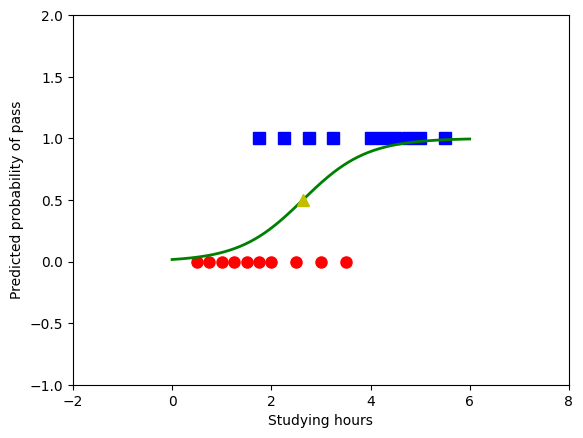

In [2]:
np.random.seed(2)

X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

X_bar = np.concatenate((np.ones((1, X.shape[1])), X), axis=0)

eta = 0.05 
d = X_bar.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X_bar, y, w_init, eta)

X0 = X_bar[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X_bar[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize=8)
plt.plot(X1, y1, 'bs', markersize=8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)

plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth=2)
plt.plot(threshold, 0.5, 'y^', markersize=8)
plt.xlabel('Studying hours')
plt.ylabel('Predicted probability of pass')
plt.show()

## 4. Thực nghiệm 2: Phân lớp dữ liệu 2 chiều (Tìm đường phân định - Decision Boundary)

Với dữ liệu nằm trong không gian 2 chiều, hàm Sigmoid sẽ tạo ra một ranh giới phân định có dạng tuyến tính (linear boundary) để chia tách hai tập dữ liệu.

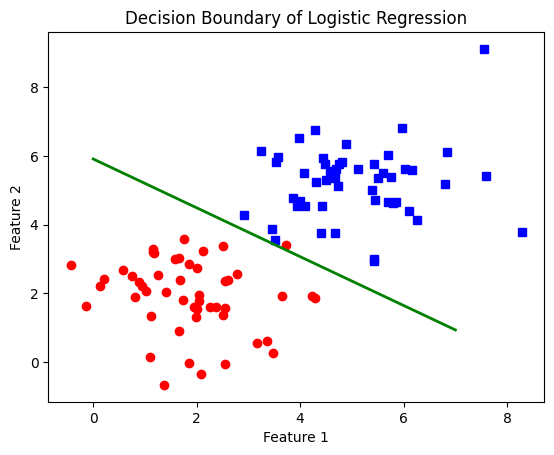

In [3]:
np.random.seed(2)

X0_2d = np.random.randn(2, 50) + np.array([[2], [2]])
X1_2d = np.random.randn(2, 50) + np.array([[5], [5]])
X_2d = np.concatenate((X0_2d, X1_2d), axis=1)
y_2d = np.concatenate((np.zeros(50), np.ones(50)))

X_2d_bar = np.concatenate((np.ones((1, 100)), X_2d), axis=0)

eta = 0.05
d = X_2d_bar.shape[0]
w_init_2d = np.random.randn(d, 1)

w_2d = logistic_sigmoid_regression(X_2d_bar, y_2d, w_init_2d, eta)

w0_2d, w1_2d, w2_2d = w_2d[-1][0][0], w_2d[-1][1][0], w_2d[-1][2][0]

x1_plot = np.linspace(0, 7, 100)
x2_plot = -(w0_2d + w1_2d*x1_plot) / w2_2d

plt.plot(X0_2d[0, :], X0_2d[1, :], 'ro', markersize=6)
plt.plot(X1_2d[0, :], X1_2d[1, :], 'bs', markersize=6)
plt.plot(x1_plot, x2_plot, 'g-', linewidth=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary of Logistic Regression')
plt.show()